In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from skimage import measure
from skimage.color import label2rgb
from skimage.io import imread

In [15]:
# Block 1 - Parameters
# Edit these variables before running the rest of the notebook.
# ---------------------------------------------------------------------
#MASK_PATH = '/Users/hectorlopezmoreno/Documents/UWMadison/multiOmic_project/Microscopy/cell_measurement/imgs-masks_sample/S5_out_mesocarp_BG_2A-007-20x_seg.npy'
#IMAGE_PATH = '/Users/hectorlopezmoreno/Documents/UWMadison/multiOmic_project/Microscopy/cell_measurement/imgs-masks_sample/S5_out_mesocarp_BG_2A-007-20x.JPG'

MASK_PATH = '/Users/hectorlopezmoreno/Documents/UWMadison/multiOmic_project/Microscopy/cell_measurement/imgs-masks_sample/S3_out_mesocarp_M34-2B-007-20x_seg.npy'
IMAGE_PATH = '/Users/hectorlopezmoreno/Documents/UWMadison/multiOmic_project/Microscopy/cell_measurement/imgs-masks_sample/S3_out_mesocarp_M34-2B-007-20x.JPG'


#MASK_PATH  = "/Users/hectorlopezmoreno/Documents/UWMadison/multiOmic_project/Microscopy/cell_measurement/imgs-masks_sample/S1_mesocarp_M34_2A-003-40x_seg.npy"
#IMAGE_PATH = "/Users/hectorlopezmoreno/Documents/UWMadison/multiOmic_project/Microscopy/cell_measurement/imgs-masks_sample/S1_mesocarp_M34_2A-003-40x.JPG"

OUTPUT_DIR = "/Users/hectorlopezmoreno/Documents/UWMadison/multiOmic_project/Microscopy/cell_measurement/results"
 
# Pixel-to-micron conversion factor derived from the calibration slide.

#myscale = 0.6467 # 40X
myscale = 1.2890 # 20 X


SCALE = myscale
 
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
 

In [16]:
# Block 2 - Load image and mask
# ---------------------------------------------------------------------
 
image = imread(IMAGE_PATH)
 
data  = np.load(MASK_PATH, allow_pickle=True).item()
masks = data["masks"].astype(np.int32)
 
# Number of cells equals the highest label ID in the mask array
n_cells = masks.max()
 
print(f"Image shape  : {image.shape}  (height x width x channels)")
print(f"Mask shape   : {masks.shape}  (height x width)")
print(f"Cells found  : {n_cells}")

Image shape  : (400, 600, 3)  (height x width x channels)
Mask shape   : (400, 600)  (height x width)
Cells found  : 65


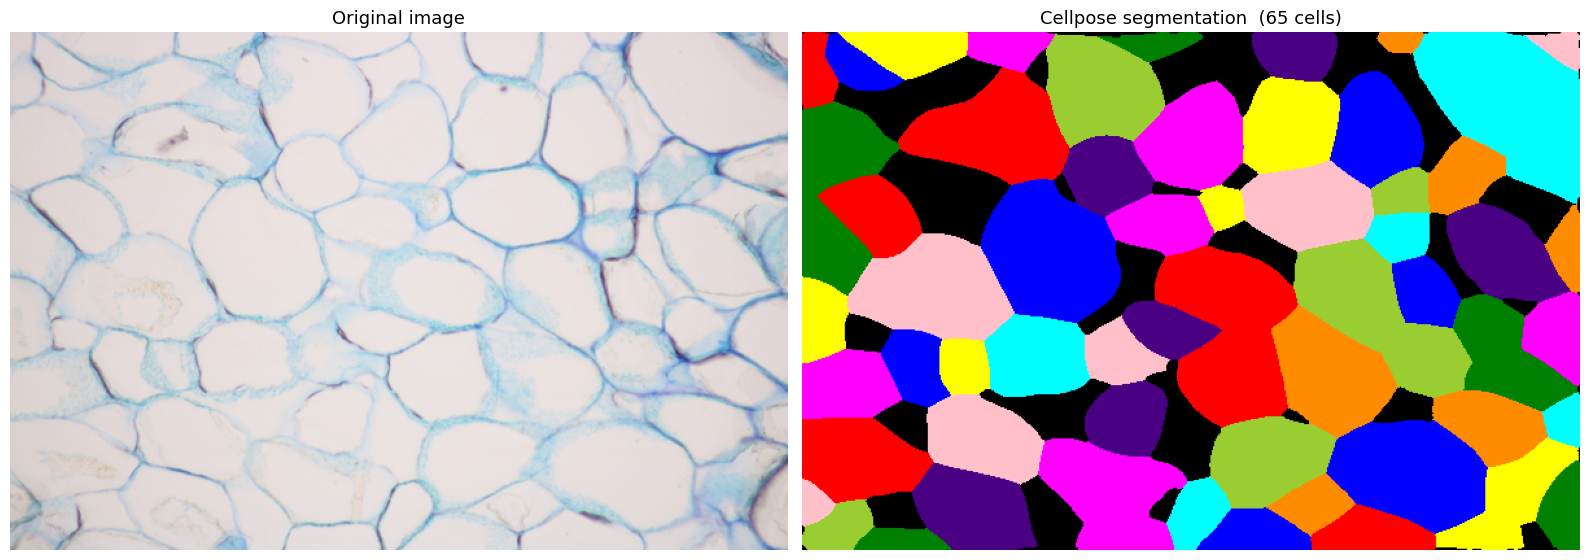

In [17]:
# Block 3 - Visualization: original image vs colored segmentation mask
# Background pixels (mask == 0) are shown in black.
# ---------------------------------------------------------------------
 
overlay = label2rgb(masks, bg_label=0, bg_color=(0, 0, 0))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
axes[0].imshow(image)
axes[0].set_title("Original image", fontsize=13)
axes[0].axis("off")
 
axes[1].imshow(overlay)
axes[1].set_title(f"Cellpose segmentation  ({n_cells} cells)", fontsize=13)
axes[1].axis("off")
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_segmentation_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
 


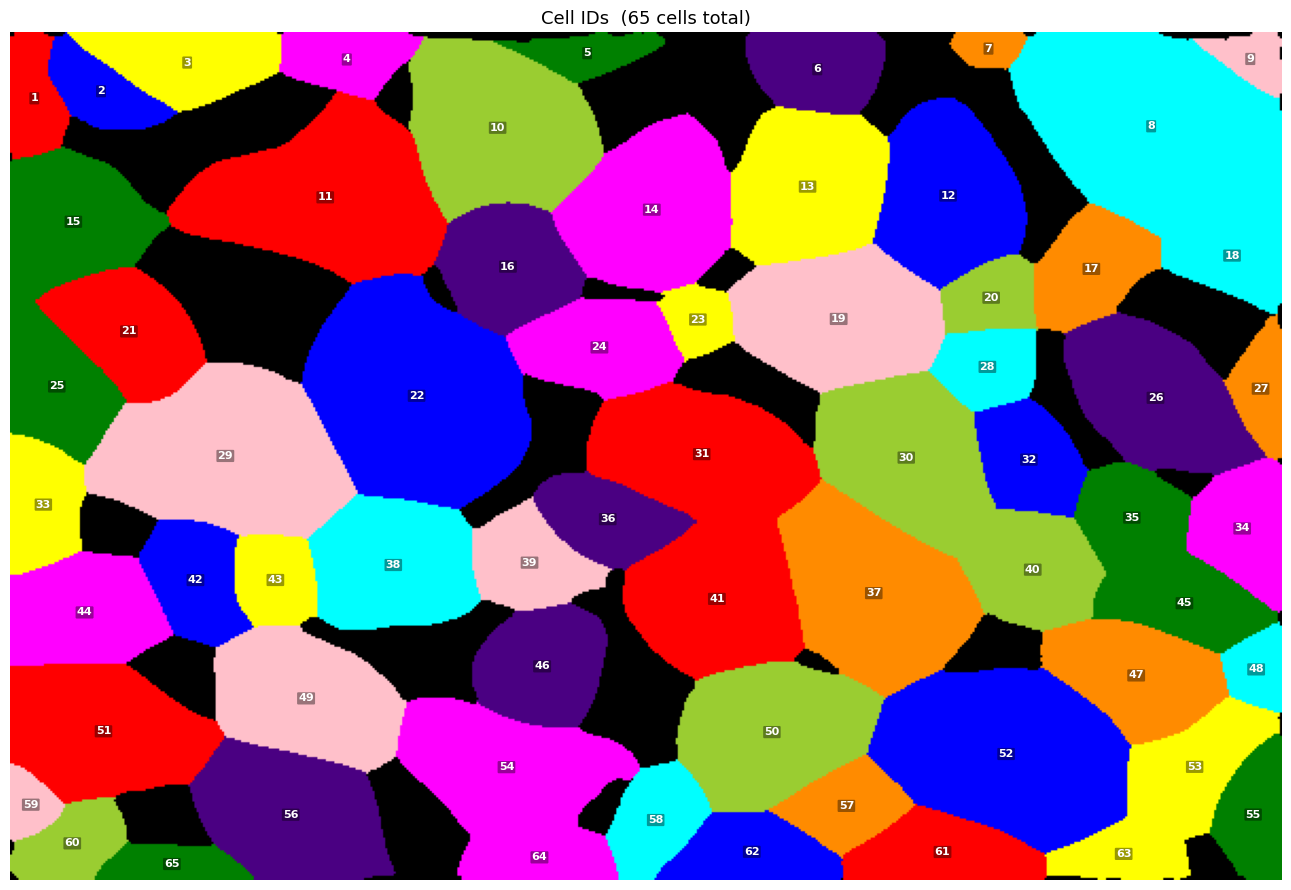

In [18]:
# Block 4 - Visualization: cell IDs overlaid on the segmentation mask
# Useful for identifying specific cells and checking the segmentation.
# ---------------------------------------------------------------------
 
props = measure.regionprops(masks)
 
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(overlay)
 
for p in props:
    r, c = p.centroid
    ax.text(c, r, str(p.label),
            fontsize=8, ha="center", va="center",
            color="white", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.1", facecolor="black",
                      alpha=0.4, linewidth=0))
 
ax.set_title(f"Cell IDs  ({n_cells} cells total)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_cell_ids.png", dpi=200, bbox_inches="tight")
plt.show()

In [19]:
# Block 5 - Identify border cells
# A cell is considered a border cell if any of its pixels touch the
# image edge (row 0, row H-1, col 0, or col W-1). Border cells are
# excluded from morphometric calculations because they are truncated.
# ---------------------------------------------------------------------
 
H, W = masks.shape
 
border_ids   = set()
interior_ids = set()
 
for p in props:
    coords = p.coords  # (N, 2) array of (row, col) pixel coordinates
    on_border = (
        np.any(coords[:, 0] == 0)     or  # top edge
        np.any(coords[:, 0] == H - 1) or  # bottom edge
        np.any(coords[:, 1] == 0)     or  # left edge
        np.any(coords[:, 1] == W - 1)     # right edge
    )
    if on_border:
        border_ids.add(p.label)
    else:
        interior_ids.add(p.label)
 
print(f"Total cells    : {n_cells}")
print(f"Border cells   : {len(border_ids)}  (excluded from measurements)")
print(f"Interior cells : {len(interior_ids)}  (used for analysis)")
 

Total cells    : 65
Border cells   : 28  (excluded from measurements)
Interior cells : 37  (used for analysis)


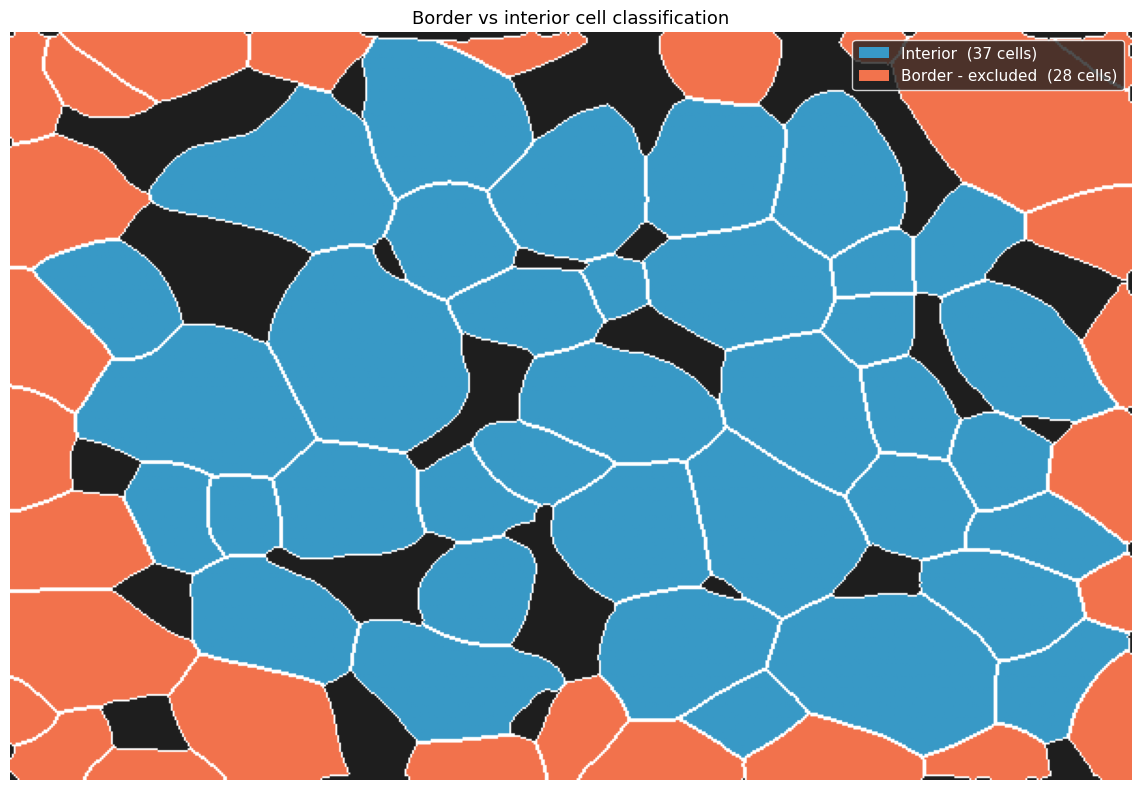

In [20]:
# %% ------------------------------------------------------------------
# Block 6 - Visualization: border vs interior cells
# Interior = steel blue  |  Border = coral  |  Background = dark gray
# Cell outlines are drawn in white for better delineation.
# ---------------------------------------------------------------------
from skimage.segmentation import find_boundaries

# Base colors
COLOR_INTERIOR = np.array([0.22, 0.60, 0.78])   # steel blue
COLOR_BORDER   = np.array([0.95, 0.45, 0.30])   # coral
COLOR_BG       = np.array([0.12, 0.12, 0.12])   # dark gray

vis = np.ones((*masks.shape, 3), dtype=np.float32) * COLOR_BG

for p in props:
    color = COLOR_BORDER if p.label in border_ids else COLOR_INTERIOR
    vis[masks == p.label] = color

# Draw cell outlines in white using boundary detection
boundaries = find_boundaries(masks, mode="inner")
vis[boundaries] = (1.0, 1.0, 1.0)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(vis)
ax.legend(
    handles=[
        Patch(facecolor=COLOR_INTERIOR, label=f"Interior  ({len(interior_ids)} cells)"),
        Patch(facecolor=COLOR_BORDER,   label=f"Border - excluded  ({len(border_ids)} cells)"),
    ],
    loc="upper right", fontsize=11,
    framealpha=0.8, edgecolor="white", facecolor="#222222",
    labelcolor="white"
)
ax.set_title("Border vs interior cell classification", fontsize=13, color="black")
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_border_vs_interior.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# Block 7 - Compute per-cell morphometric measurements
# Metrics are calculated for all cells. The column 'touches_border'
# can be used to filter out border cells downstream.
#
# Metrics:
#   area_um2       - cell area (um^2)
#   perimeter_um   - cell perimeter (um)
#   equiv_diam_um  - diameter of a circle with the same area (um)
#   major_axis_um  - length of the major axis of the fitted ellipse (um)
#   minor_axis_um  - length of the minor axis of the fitted ellipse (um)
#   eccentricity   - 0 = circle, 1 = line
#   circularity    - 4*pi*area / perimeter^2  (1 = perfect circle)
#   solidity       - area / convex hull area
#   aspect_ratio   - major_axis / minor_axis
# ---------------------------------------------------------------------
 
records = []
 
for p in props:
    area_px  = p.area
    perim_px = p.perimeter
    maj_px   = p.axis_major_length
    min_px   = p.axis_minor_length
 
    area_um2  = area_px  * SCALE ** 2
    perim_um  = perim_px * SCALE
    maj_um    = maj_px   * SCALE
    min_um    = min_px   * SCALE
    diam_um   = p.equivalent_diameter_area * SCALE
 
    circularity  = (4 * np.pi * area_px / perim_px ** 2) if perim_px > 0 else np.nan
    aspect_ratio = (maj_px / min_px) if min_px > 0 else np.nan
 
    records.append({
        "cell_id"         : p.label,
        "touches_border"  : p.label in border_ids,
        "area_um2"        : round(area_um2,      4),
        "perimeter_um"    : round(perim_um,       4),
        "equiv_diam_um"   : round(diam_um,        4),
        "major_axis_um"   : round(maj_um,         4),
        "minor_axis_um"   : round(min_um,         4),
        "eccentricity"    : round(p.eccentricity, 4),
        "circularity"     : round(circularity,    4),
        "solidity"        : round(p.solidity,     4),
        "aspect_ratio"    : round(aspect_ratio,   4),
        "centroid_row_px" : round(p.centroid[0],  2),
        "centroid_col_px" : round(p.centroid[1],  2),
    })
 
df_all      = pd.DataFrame(records)
df_interior = df_all[~df_all["touches_border"]].copy().reset_index(drop=True)
 
print(f"df_all rows      : {len(df_all)}  (all cells)")
print(f"df_interior rows : {len(df_interior)}  (interior cells only)")
print()
print(df_interior.head())

df_all rows      : 65  (all cells)
df_interior rows : 37  (interior cells only)

   cell_id  touches_border    area_um2  perimeter_um  equiv_diam_um  \
0       10           False   9829.5582      399.9120       111.8722   
1       11           False  11790.1530      474.4685       122.5222   
2       12           False   7573.2127      344.7061        98.1963   
3       13           False   7647.9812      338.8173        98.6798   
4       14           False   8405.6347      353.3784       103.4523   

   major_axis_um  minor_axis_um  eccentricity  circularity  solidity  \
0       125.8965       102.6201        0.5793       0.7724    0.9458   
1       162.6890       102.1429        0.7783       0.6581    0.9073   
2       111.8434        88.6225        0.6100       0.8009    0.9544   
3       107.1086        92.3840        0.5060       0.8372    0.9754   
4       114.0825        95.6195        0.5454       0.8459    0.9774   

   aspect_ratio  centroid_row_px  centroid_col_px  
0      

In [22]:
# %% ------------------------------------------------------------------
# Block 8 - Save per-cell measurements to CSV
# ---------------------------------------------------------------------
 
df_all.to_csv(f"{OUTPUT_DIR}/cells_all.csv",           index=False)
df_interior.to_csv(f"{OUTPUT_DIR}/cells_interior.csv", index=False)
 
print(f"Saved: {OUTPUT_DIR}/cells_all.csv")
print(f"Saved: {OUTPUT_DIR}/cells_interior.csv")

Saved: /Users/hectorlopezmoreno/Documents/UWMadison/multiOmic_project/Microscopy/cell_measurement/results/cells_all.csv
Saved: /Users/hectorlopezmoreno/Documents/UWMadison/multiOmic_project/Microscopy/cell_measurement/results/cells_interior.csv


In [23]:
# Block 9 - Descriptive statistics (interior cells only)
# ---------------------------------------------------------------------
 
metric_cols = ["area_um2", "equiv_diam_um", "circularity",
               "solidity", "eccentricity", "aspect_ratio"]
 
summary = df_interior[metric_cols].describe().T.round(3)
print(summary.to_string())
 
summary.to_csv(f"{OUTPUT_DIR}/summary_interior.csv")

               count      mean       std       min       25%       50%       75%        max
area_um2        37.0  6492.371  3223.423  1543.553  3676.946  5743.878  8405.635  14262.496
equiv_diam_um   37.0    88.108    22.745    44.332    68.422    85.518   103.452    134.758
circularity     37.0     0.764     0.065     0.604     0.730     0.773     0.814      0.858
solidity        37.0     0.951     0.029     0.843     0.948     0.963     0.969      0.977
eccentricity    37.0     0.685     0.132     0.446     0.579     0.717     0.782      0.891
aspect_ratio    37.0     1.462     0.272     1.117     1.227     1.435     1.604      2.205


In [24]:
# Block 10 - Image-level statistics
# ---------------------------------------------------------------------
 
total_px    = H * W
bg_px       = np.sum(masks == 0)
total_area  = total_px * SCALE ** 2
bg_area     = bg_px    * SCALE ** 2
cell_area   = df_all["area_um2"].sum()
density_mm2 = len(df_all) / total_area * 1e6
 
print(f"Total cells            : {len(df_all)}")
print(f"Interior cells         : {len(df_interior)}")
print(f"Image area             : {total_area:,.1f} um^2")
print(f"Total cell area        : {cell_area:,.1f} um^2")
print(f"Intercellular area     : {bg_area:,.1f} um^2")
print(f"Intercellular fraction : {100 * bg_px / total_px:.2f} %")
print(f"Cell density           : {density_mm2:.1f} cells/mm^2")

Total cells            : 65
Interior cells         : 37
Image area             : 398,765.0 um^2
Total cell area        : 343,456.3 um^2
Intercellular area     : 55,308.7 um^2
Intercellular fraction : 13.87 %
Cell density           : 163.0 cells/mm^2


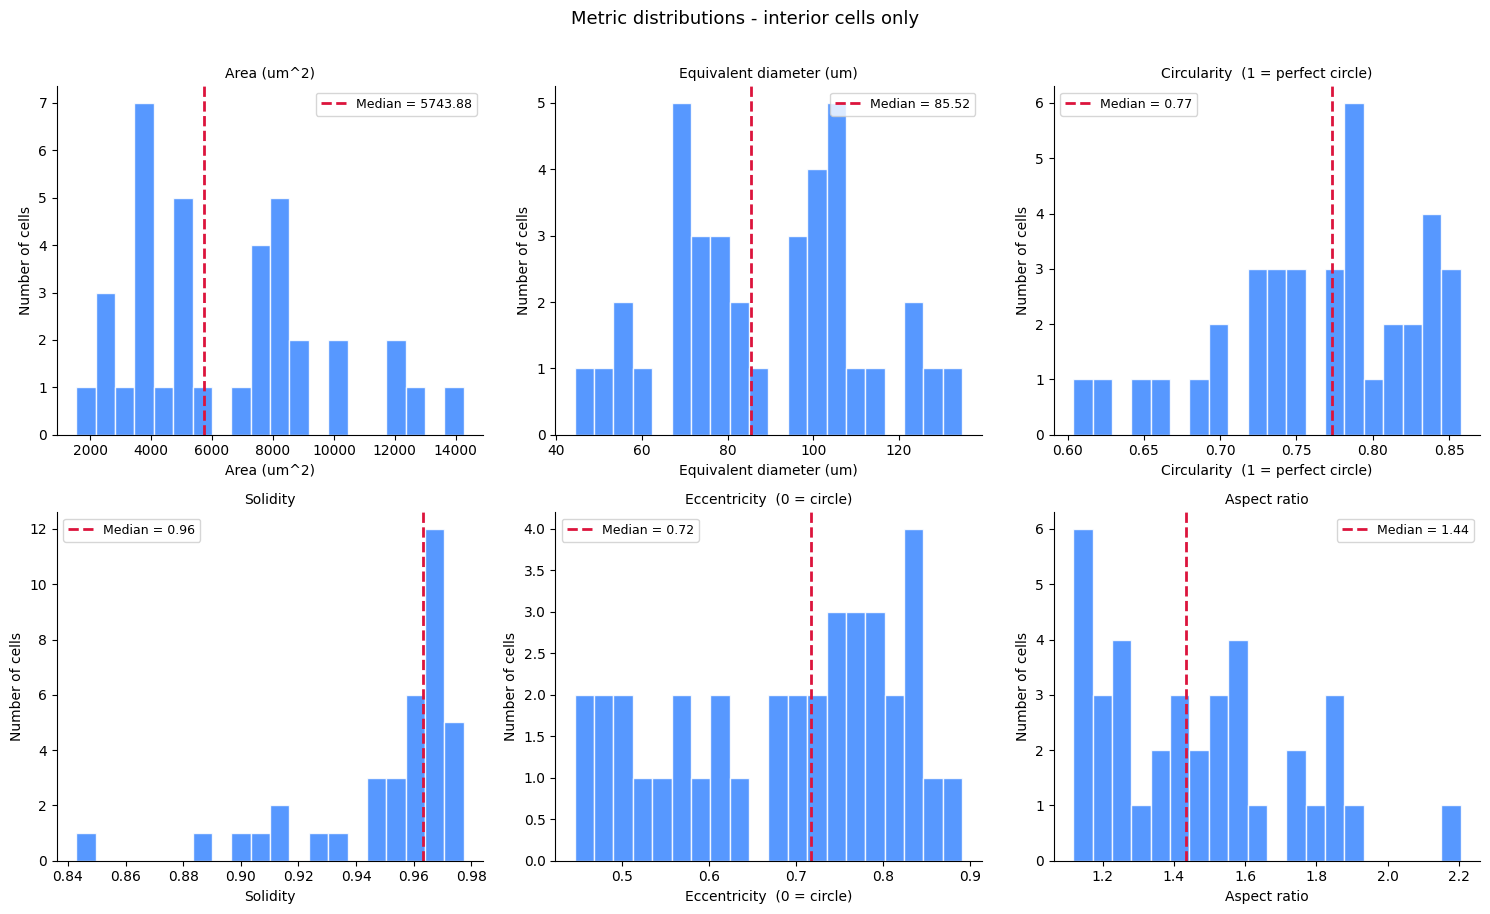

In [25]:
# Block 11 - Histograms of morphometric metrics (interior cells)
# ---------------------------------------------------------------------
 
col_labels = {
    "area_um2"      : "Area (um^2)",
    "equiv_diam_um" : "Equivalent diameter (um)",
    "circularity"   : "Circularity  (1 = perfect circle)",
    "solidity"      : "Solidity",
    "eccentricity"  : "Eccentricity  (0 = circle)",
    "aspect_ratio"  : "Aspect ratio",
}
 
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
 
for ax, (col, label) in zip(axes.flat, col_labels.items()):
    data = df_interior[col].dropna()
    ax.hist(data, bins=20, color="#3a86ff", edgecolor="white", alpha=0.85)
    med = data.median()
    ax.axvline(med, color="crimson", lw=2, ls="--", label=f"Median = {med:.2f}")
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Number of cells", fontsize=10)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
 
plt.suptitle("Metric distributions - interior cells only", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

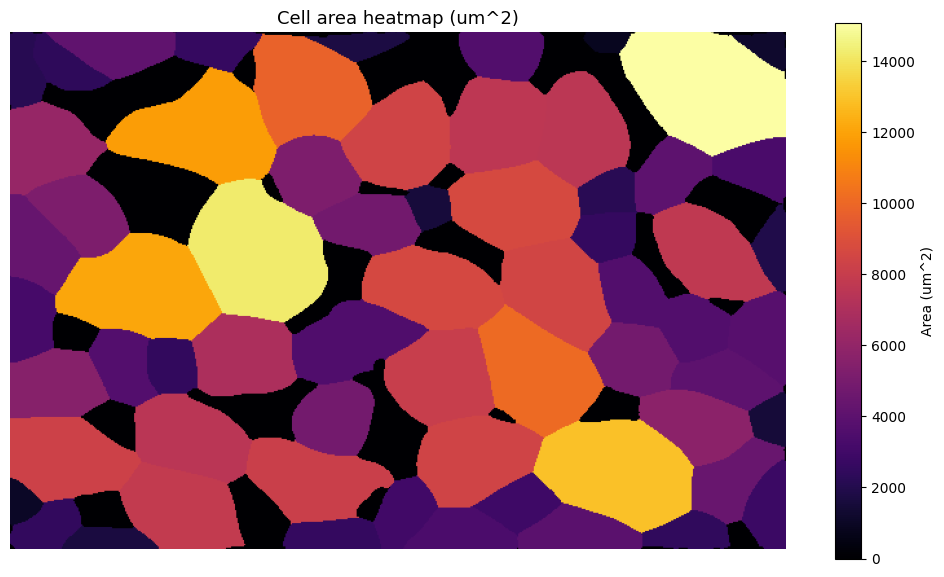

In [26]:
# Block 12 - Area heatmap
# Each cell is colored by its area value. Background is black.
# ---------------------------------------------------------------------
 
area_map = np.zeros_like(masks, dtype=float)
for _, row in df_all.iterrows():
    area_map[masks == int(row["cell_id"])] = row["area_um2"]
 
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(area_map, cmap="inferno")
plt.colorbar(im, ax=ax, shrink=0.8, label="Area (um^2)")
ax.set_title("Cell area heatmap (um^2)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_area_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

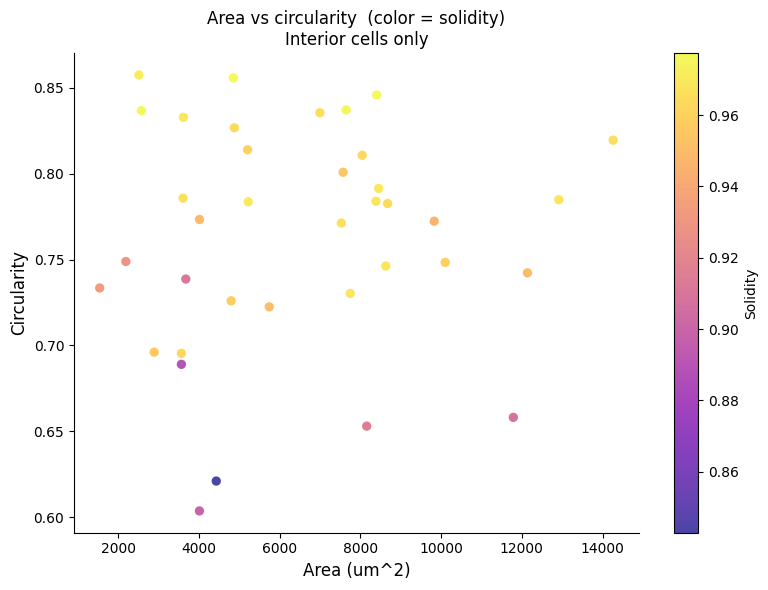

In [27]:
# Block 13 - Scatter plot: area vs circularity, colored by solidity
# ---------------------------------------------------------------------
 
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    df_interior["area_um2"],
    df_interior["circularity"],
    c=df_interior["solidity"],
    cmap="plasma",
    alpha=0.75,
    edgecolors="none",
    s=45,
)
plt.colorbar(sc, ax=ax, label="Solidity")
ax.set_xlabel("Area (um^2)", fontsize=12)
ax.set_ylabel("Circularity", fontsize=12)
ax.set_title("Area vs circularity  (color = solidity)\nInterior cells only", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_scatter.png", dpi=150, bbox_inches="tight")
plt.show()